<a href="https://colab.research.google.com/github/saniaali48/Student-result-analysis-/blob/main/Student_Result_Analysis_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
os.getcwd()

'C:\\Users\\Pakistan'

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
df=pd.read_csv("D:\\student_result.csv")
print(df.head())


   Unnamed  Gender ParentMaritalStatus IsFristChild TransportMean  \
0        1    Male              Single          Yes           Bus   
1        2    Male              Single           No          Bike   
2        3  Female            Divorced          Yes           Bus   
3        4    Male             Married           No           Bus   
4        5    Male              Single          Yes           Car   

        TestPrep  WritingScore  ReadingScore  MathScore     LunchType  \
0      Completed            39            41         35  Free/Reduced   
1  Not Completed            81            72         64  Free/Reduced   
2  Not Completed            45            49         59      Standard   
3  Not Completed            90            86         93  Free/Reduced   
4  Not Completed            88            89         78  Free/Reduced   

  PracticeSport  NrSibling ParentEducation EthnicGroup  
0     Regularly          0     High School     Group B  
1     Regularly          1      

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Unnamed              500 non-null    int64
 1   Gender               500 non-null    str  
 2   ParentMaritalStatus  500 non-null    str  
 3   IsFristChild         500 non-null    str  
 4   TransportMean        500 non-null    str  
 5   TestPrep             500 non-null    str  
 6   WritingScore         500 non-null    int64
 7   ReadingScore         500 non-null    int64
 8   MathScore            500 non-null    int64
 9   LunchType            500 non-null    str  
 10  PracticeSport        500 non-null    str  
 11  NrSibling            500 non-null    int64
 12  ParentEducation      500 non-null    str  
 13  EthnicGroup          500 non-null    str  
dtypes: int64(5), str(9)
memory usage: 54.8 KB


In [ ]:
print(df.describe())

          Unnamed  WritingScore  ReadingScore   MathScore   NrSibling
count  500.000000    500.000000    500.000000  500.000000  500.000000
mean   250.500000     71.376000     70.796000   70.874000    2.428000
std    144.481833     17.433142     17.030398   18.144547    1.718931
min      1.000000     35.000000     40.000000   30.000000    0.000000
25%    125.750000     58.750000     57.000000   57.000000    1.000000
50%    250.500000     72.000000     72.000000   72.000000    2.000000
75%    375.250000     86.000000     86.000000   86.000000    4.000000
max    500.000000    100.000000    100.000000  100.000000    5.000000


In [ ]:
print(df.isnull().sum())

Unnamed                0
Gender                 0
ParentMaritalStatus    0
IsFristChild           0
TransportMean          0
TestPrep               0
WritingScore           0
ReadingScore           0
MathScore              0
LunchType              0
PracticeSport          0
NrSibling              0
ParentEducation        0
EthnicGroup            0
dtype: int64


#Total Score Of Student

In [ ]:
df["TotalScore"]=df["MathScore"]+df["ReadingScore"]+df["WritingScore"]
print(df)

     Unnamed  Gender ParentMaritalStatus IsFristChild TransportMean  \
0          1    Male              Single          Yes           Bus   
1          2    Male              Single           No          Bike   
2          3  Female            Divorced          Yes           Bus   
3          4    Male             Married           No           Bus   
4          5    Male              Single          Yes           Car   
..       ...     ...                 ...          ...           ...   
495      496  Female              Single           No           Car   
496      497  Female            Divorced          Yes           Van   
497      498    Male            Divorced           No           Van   
498      499  Female              Single           No          Bike   
499      500  Female             Widowed           No          Bike   

          TestPrep  WritingScore  ReadingScore  MathScore     LunchType  \
0        Completed            39            41         35  Free/Reduced 

#Drop Unnamed Column

In [ ]:
df=df.drop("Unnamed", axis=1)
print(df)

     Gender ParentMaritalStatus IsFristChild TransportMean       TestPrep  \
0      Male              Single          Yes           Bus      Completed   
1      Male              Single           No          Bike  Not Completed   
2    Female            Divorced          Yes           Bus  Not Completed   
3      Male             Married           No           Bus  Not Completed   
4      Male              Single          Yes           Car  Not Completed   
..      ...                 ...          ...           ...            ...   
495  Female              Single           No           Car  Not Completed   
496  Female            Divorced          Yes           Van  Not Completed   
497    Male            Divorced           No           Van  Not Completed   
498  Female              Single           No          Bike  Not Completed   
499  Female             Widowed           No          Bike  Not Completed   

     WritingScore  ReadingScore  MathScore     LunchType PracticeSport  \
0

#Rename IsFristChild Column

In [ ]:
df=df.rename(columns={"IsFristChild":"IsFirtstChild"})
print(df.head())

   Gender ParentMaritalStatus IsFirtstChild TransportMean       TestPrep  \
0    Male              Single           Yes           Bus      Completed   
1    Male              Single            No          Bike  Not Completed   
2  Female            Divorced           Yes           Bus  Not Completed   
3    Male             Married            No           Bus  Not Completed   
4    Male              Single           Yes           Car  Not Completed   

   WritingScore  ReadingScore  MathScore     LunchType PracticeSport  \
0            39            41         35  Free/Reduced     Regularly   
1            81            72         64  Free/Reduced     Regularly   
2            45            49         59      Standard     Sometimes   
3            90            86         93  Free/Reduced         Never   
4            88            89         78  Free/Reduced         Never   

   NrSibling ParentEducation EthnicGroup  TotalScore  
0          0     High School     Group B         115  


#Maximum MathScore For Each PracticeSport Category


In [ ]:
df.groupby("PracticeSport")["MathScore"].max()

PracticeSport
Never        100
Regularly    100
Sometimes    100
Name: MathScore, dtype: int64

#ParentEducation Wise Average of WritingScore Of Only Female Students

In [ ]:
df[df["Gender"]=="Female"].groupby("ParentEducation")["WritingScore"].mean().sort_values(ascending=False)

ParentEducation
Master          72.200000
PhD             71.540000
High School     71.272727
Bachelor        70.159091
Intermediate    68.894737
Name: WritingScore, dtype: float64

#Gender Distribution

<function matplotlib.pyplot.show(close=None, block=None)>

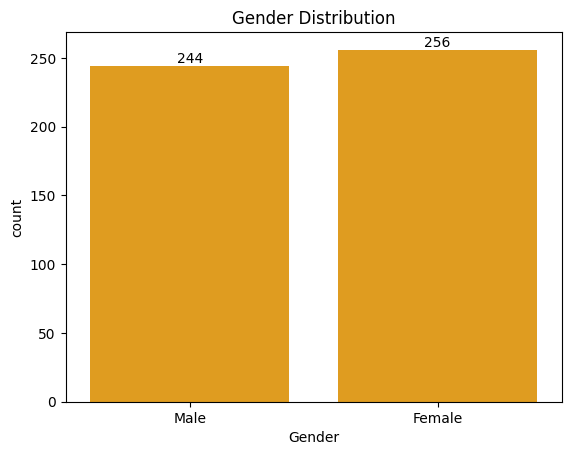

In [ ]:
ax=sns.countplot(data=df, x="Gender", color="orange")
ax.bar_label(ax.containers[0])
plt.title("Gender Distribution")
plt.show

In [ ]:
# from above chart we analyze:
# that number of female is more then number of males


In [ ]:
gb = df.groupby("ParentEducation").agg({"MathScore":'mean',"ReadingScore":'mean',"WritingScore":'mean'})
print(gb)



                 MathScore  ReadingScore  WritingScore
ParentEducation                                       
Bachelor         71.409091     70.897727     71.272727
High School      69.611111     70.777778     71.370370
Intermediate     70.028846     69.423077     70.519231
Master           72.309278     71.824742     72.082474
PhD              71.242718     71.145631     71.669903


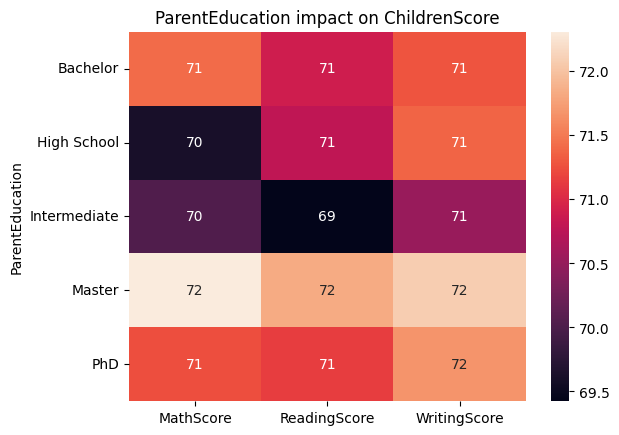

In [ ]:
sns.heatmap(gb, annot=True)
plt.title("ParentEducation impact on ChildrenScore")
plt.show()

In [ ]:
#Conclusion
#Heigher Education of Parent Impact positivly of his/her childscore but limited

#Impact of ParentMaritalStatus On ChildScore


In [ ]:
gs=df.groupby("ParentMaritalStatus").agg({"MathScore":'mean',"ReadingScore":'mean',"WritingScore":'mean'})
print(gs)

                     MathScore  ReadingScore  WritingScore
ParentMaritalStatus                                       
Divorced             70.955556     70.577778     71.637037
Married              73.336449     72.953271     74.186916
Single               68.447761     68.865672     68.850746
Widowed              71.282258     71.258065     71.395161


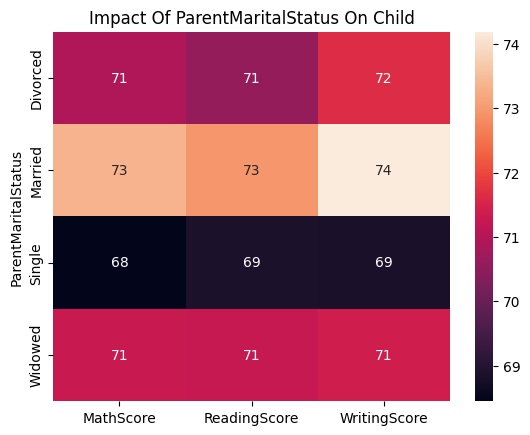

In [ ]:
sns.heatmap(gs, annot=True)
plt.title("Impact Of ParentMaritalStatus On Child")
plt.show()

In [ ]:
#ParentMarital Status Effect Child Success children of maried people perform better as compared to single,window or divorced


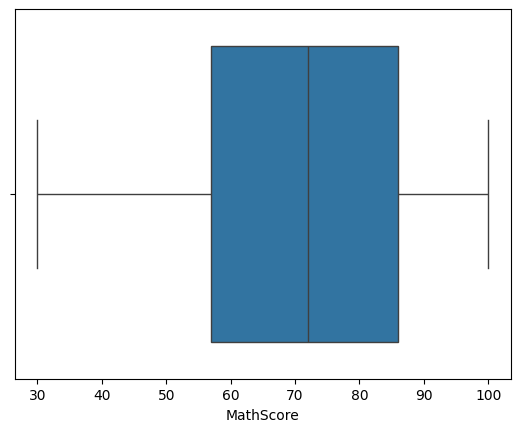

In [ ]:
sns.boxplot(data=df, x="MathScore")
plt.show()

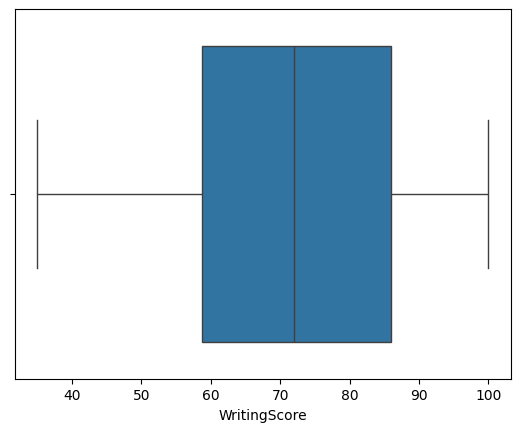

In [ ]:
sns.boxplot(data=df, x="WritingScore")
plt.show()

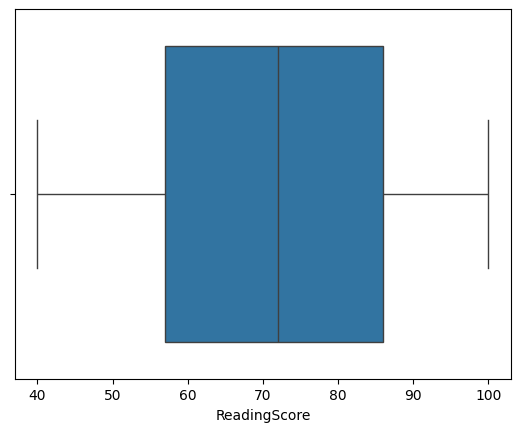

In [ ]:
sns.boxplot(data=df, x="ReadingScore")
plt.show()

In [ ]:
print(df["EthnicGroup"].unique())

<StringArray>
['Group B', 'Group C', 'Group A', 'Group D']
Length: 4, dtype: str


Distribution of Ethnic Group

[np.int64(128), np.int64(119), np.int64(134), np.int64(119)]


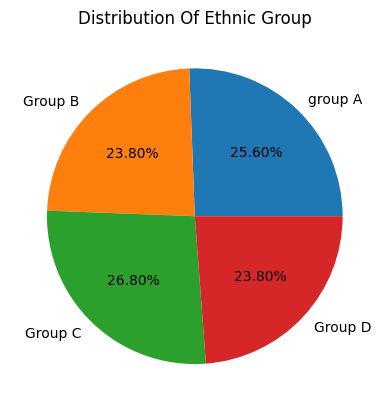

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

groupA=df.loc[(df["EthnicGroup"]=="Group A")].count()["EthnicGroup"]
groupB=df.loc[(df["EthnicGroup"]=="Group B")].count()["EthnicGroup"]
groupC=df.loc[(df["EthnicGroup"]=="Group C")].count()["EthnicGroup"]
groupD=df.loc[(df["EthnicGroup"]=="Group D")].count()["EthnicGroup"]
l=["group A","Group B","Group C","Group D"]
mlist= [groupA,groupB,groupC, groupD]
print(mlist)
plt.pie(mlist, labels=l, autopct="%1.2f%%")
plt.title("Distribution Of Ethnic Group")
plt.show()

AttributeError: 'Axes' object has no attribute 'countainers'

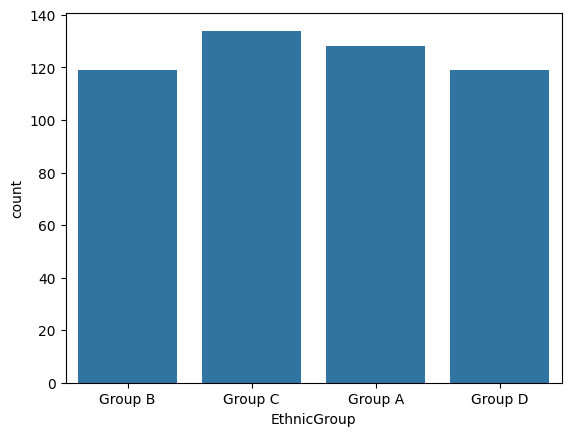

In [ ]:
ax=sns.countplot(data=df, x="EthnicGroup")
ax.bar_label(ax.countainers[0])